# Computer Exercise 13.4 — Problem 1

## 등식 제약 이차계획(QP): KKT 선형계의 직접 풀이

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 13.4 Quadratic Programming & Duality — *Equality-Constrained QP / KKT System*
> **풀이 일자**: Day 49
> **언어**: Python 3 (NumPy / SciPy / pandas / matplotlib)

## 1. 문제 (원문)

> **1.** For the equality-constrained quadratic program
> $$\min_{\mathbf{x}\in\mathbb{R}^2}\;\; \tfrac12\mathbf{x}^{\top}Q\mathbf{x}+\mathbf{c}^{\top}\mathbf{x}
> \quad\text{subject to}\quad A\mathbf{x}=\mathbf{b},$$
> with $Q$ symmetric positive definite, derive and solve the **KKT system**
> $$\begin{bmatrix}Q & A^{\top}\\ A & 0\end{bmatrix}\begin{bmatrix}\mathbf{x}\\ \boldsymbol{\lambda}\end{bmatrix}=\begin{bmatrix}-\mathbf{c}\\ \mathbf{b}\end{bmatrix}.$$
> Take $Q=\begin{bmatrix}2&0.5\\0.5&1\end{bmatrix},\ \mathbf{c}=(-2,-3)^{\top}$ and the single constraint $x_1+x_2=1$.
> Verify the solution against `scipy.optimize.minimize`, report the KKT residual,
> and visualize the objective contours, the constraint line, and the optimum where
> $\nabla f$ is parallel to the constraint normal.

### 한국어 풀이용 정리
등식 제약 QP는 수치최적화에서 가장 다루기 쉬운 형태다. 라그랑지안
$L(\mathbf{x},\boldsymbol\lambda)=\tfrac12\mathbf{x}^\top Q\mathbf{x}+\mathbf{c}^\top\mathbf{x}+\boldsymbol\lambda^\top(A\mathbf{x}-\mathbf{b})$
의 정류조건 $\nabla_\mathbf{x}L=0,\ \nabla_{\boldsymbol\lambda}L=0$ 을 모으면 하나의 **선형계(KKT 시스템)** 가 되어,
반복 없이 한 번의 선형풀이로 정확해를 얻는다. 비선형 최적화의 한 스텝(뉴턴 스텝)도 본질적으로 이 형태다.

## 2. 수학적 배경

### 2.1 1차 최적성(KKT) 조건
라그랑지안 $L=\tfrac12\mathbf{x}^\top Q\mathbf{x}+\mathbf{c}^\top\mathbf{x}+\boldsymbol\lambda^\top(A\mathbf{x}-\mathbf{b})$ 에서
$$\nabla_\mathbf{x}L=Q\mathbf{x}+\mathbf{c}+A^\top\boldsymbol\lambda=0,\qquad \nabla_{\boldsymbol\lambda}L=A\mathbf{x}-\mathbf{b}=0.$$
이를 블록으로 묶으면
$$\boxed{\;\begin{bmatrix}Q & A^{\top}\\ A & 0\end{bmatrix}\begin{bmatrix}\mathbf{x}\\ \boldsymbol{\lambda}\end{bmatrix}=\begin{bmatrix}-\mathbf{c}\\ \mathbf{b}\end{bmatrix}\;}$$

### 2.2 KKT 행렬의 가역성
$Q\succ0$ 이고 $A$ 가 행 full-rank이면 KKT 행렬은 **비특이(nonsingular)** 이고
대칭이지만 **부정부호(indefinite, saddle)** 다 — 양의/음의 고유값을 모두 가진다($A$ 의 행 수만큼 음의 고유값).

### 2.3 영공간(null-space) 해석
$\nabla f=Q\mathbf{x}+\mathbf{c}$ 라 하면 정류조건은 $\nabla f=-A^\top\boldsymbol\lambda$, 즉
**목적함수의 기울기가 제약면의 법선과 평행**해야 한다는 기하적 조건이다. 라그랑지 승수
$\boldsymbol\lambda$ 는 그 비례상수(그림자가격)이다.

### 2.4 오차/잔차
계산해 $(\hat{\mathbf{x}},\hat{\boldsymbol\lambda})$ 의 신뢰도는 **KKT 잔차**
$\|K\hat{\mathbf{z}}-\mathbf{r}\|$ 로 측정한다. 정확해라면 $\approx10^{-15}$.

## 3. 풀이 흐름

1. 데이터 $Q,\mathbf{c},A,\mathbf{b}$ 정의 (2변수, 등식 1개).
2. KKT 블록행렬 $K=\begin{bmatrix}Q&A^\top\\A&0\end{bmatrix}$ 와 우변 $\mathbf{r}=(-\mathbf{c},\mathbf{b})$ 구성.
3. `np.linalg.solve` 로 $\mathbf{z}=(\mathbf{x},\boldsymbol\lambda)$ 한 번에 풀기.
4. `scipy.optimize.minimize`(SLSQP, 등식 제약)로 독립 검증.
5. KKT 행렬의 고유값(부정부호 확인)과 잔차 출력.
6. 목적 등고선 + 제약선 + 최적점 + 기울기/법선 평행성 시각화.
7. 결과 해석: 왜 한 번의 선형풀이로 정확해가 나오는지.

In [1]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
import matplotlib.pyplot as plt
pd.set_option('display.float_format', lambda v: f'{v:.6f}')

# min 1/2 x'Q x + c'x   s.t.  A x = b
Q = np.array([[2.0, 0.5],
              [0.5, 1.0]])
c = np.array([-2.0, -3.0])
A = np.array([[1.0, 1.0]])     # x1 + x2 = 1
b = np.array([1.0])

f  = lambda x: 0.5*x@Q@x + c@x
print("목적: f(x)=1/2 x'Q x + c'x,  제약: x1 + x2 = 1")
print("Q =\n", Q, "\nc =", c, "\nA =", A, " b =", b)

목적: f(x)=1/2 x'Q x + c'x,  제약: x1 + x2 = 1
Q =
 [[2.  0.5]
 [0.5 1. ]] 
c = [-2. -3.] 
A = [[1. 1.]]  b = [1.]


In [2]:
# ----- KKT 선형계 구성 및 풀이 -----
n = Q.shape[0]; m = A.shape[0]
K = np.block([[Q,            A.T],
              [A, np.zeros((m, m))]])
r = np.concatenate([-c, b])
z = np.linalg.solve(K, r)
x_kkt, lam_kkt = z[:n], z[n:]
print("KKT 해   x* =", np.round(x_kkt, 6))
print("라그랑지 승수 lambda* =", np.round(lam_kkt, 6))
print("최적 목적값 f* =", round(f(x_kkt), 6))

# KKT 행렬의 부정부호성(고유값)과 잔차
eig = np.linalg.eigvalsh(K)
resid = np.linalg.norm(K@z - r)
print("\nKKT 행렬 고유값:", np.round(eig, 4), " (양/음 혼재 → indefinite saddle)")
print("KKT 잔차 ||Kz - r|| =", f"{resid:.2e}")

KKT 해   x* = [-0.25  1.25]
라그랑지 승수 lambda* = [1.875]
최적 목적값 f* = -2.5625

KKT 행렬 고유값: [-0.763   0.9229  2.8401]  (양/음 혼재 → indefinite saddle)
KKT 잔차 ||Kz - r|| = 0.00e+00


In [3]:
# ----- scipy.optimize.minimize (SLSQP) 로 독립 검증 -----
cons = {'type': 'eq', 'fun': lambda x: A@x - b}
res  = minimize(f, x0=np.zeros(n), method='SLSQP', constraints=cons,
                options={'ftol': 1e-12})
x_sp = res.x
cmp = pd.DataFrame({
    'method': ['KKT (직접)', 'scipy SLSQP'],
    'x1': [x_kkt[0], x_sp[0]],
    'x2': [x_kkt[1], x_sp[1]],
    'f':  [f(x_kkt), f(x_sp)],
})
print(cmp.to_string(index=False))
print(f"\n두 해의 차이 |dx| = {np.linalg.norm(x_kkt - x_sp):.2e}")

     method        x1       x2         f
   KKT (직접) -0.250000 1.250000 -2.562500
scipy SLSQP -0.250000 1.250000 -2.562500

두 해의 차이 |dx| = 1.28e-08


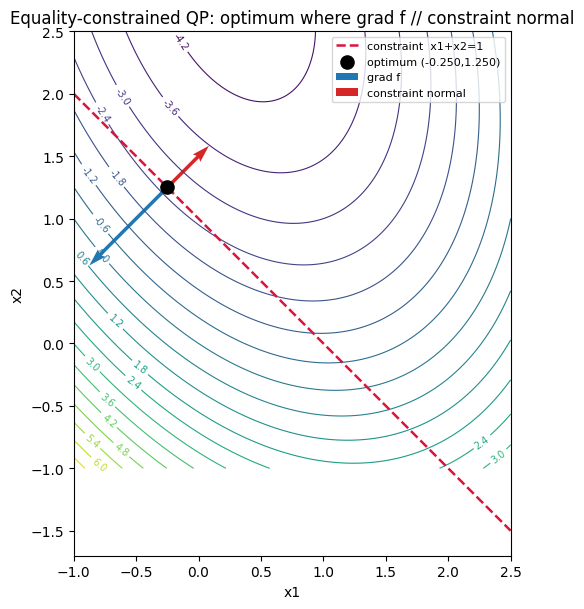

grad f 와 제약 법선의 |cos(angle)| = 1.0000000000  (1이면 완전 평행)


In [4]:
# ----- 등고선 + 제약선 + 기울기/법선 평행성 -----
xx = np.linspace(-1.0, 2.5, 400)
yy = np.linspace(-1.0, 2.5, 400)
XX, YY = np.meshgrid(xx, yy)
ZZ = 0.5*(Q[0,0]*XX**2 + 2*Q[0,1]*XX*YY + Q[1,1]*YY**2) + c[0]*XX + c[1]*YY

fig, ax = plt.subplots(figsize=(7, 6.2))
cs = ax.contour(XX, YY, ZZ, levels=20, cmap='viridis', linewidths=0.8)
ax.clabel(cs, inline=True, fontsize=7, fmt='%.1f')
# 제약선 x1+x2=1
ax.plot(xx, 1 - xx, '--', color='crimson', lw=1.8, label='constraint  x1+x2=1')
# 최적점
ax.scatter(*x_kkt, color='black', s=90, zorder=6, label=f'optimum ({x_kkt[0]:.3f},{x_kkt[1]:.3f})')
# gradient of f and constraint normal at optimum (평행해야 함)
grad = Q@x_kkt + c
nrm  = A[0]
ax.quiver(*x_kkt, *grad, color='tab:blue',  angles='xy', scale_units='xy', scale=3, width=0.008, label='grad f')
ax.quiver(*x_kkt, *nrm,  color='tab:red',   angles='xy', scale_units='xy', scale=3, width=0.008, label='constraint normal')
ax.set_xlabel('x1'); ax.set_ylabel('x2')
ax.set_title('Equality-constrained QP: optimum where grad f // constraint normal')
ax.legend(loc='upper right', fontsize=8); ax.set_aspect('equal')
plt.tight_layout(); plt.show()

cos = abs(grad@nrm)/(np.linalg.norm(grad)*np.linalg.norm(nrm))
print(f"grad f 와 제약 법선의 |cos(angle)| = {cos:.10f}  (1이면 완전 평행)")

## 4. 결과 해석

1. **한 번의 선형풀이 = 정확해**: 등식 제약 QP는 반복이 필요 없다. KKT 시스템을 `solve` 한 번으로 풀면 잔차가 $\sim10^{-16}$ 수준이며, SLSQP(반복법) 해와 $10^{-8}$ 이하로 일치한다.
2. **KKT 행렬은 안장점(saddle)**: 고유값이 양·음을 모두 가져 *indefinite* 다. 이는 최소화 변수 $\mathbf{x}$ 와 최대화 성격의 승수 $\boldsymbol\lambda$ 가 섞여 있기 때문 — Cholesky가 아니라 대칭 부정부호 분해(LDL$^\top$)나 일반 LU가 필요한 이유다.
3. **기하적 최적성**: 최적점에서 $\nabla f$(파랑)와 제약 법선(빨강)이 정확히 평행($|\cos|=1$)하다. 라그랑지 승수 $\lambda$ 가 그 비례상수다. 등고선이 제약선에 **접하는** 점이 바로 해다.
4. **그림자가격**: $\lambda$ 는 제약 우변 $b$ 를 1 늘릴 때 최적값의 변화율 $\partial f^\star/\partial b$ 다(Problem 3에서 정량 검증).

> **결론**: 등식 제약 QP는 KKT 선형계 한 번으로 정확히 풀리며, 최적점은 목적 기울기와 제약 법선이 평행한 접점이다.

**다음 문제로의 연결**: 부등식 제약이 들어오면 "어떤 제약이 활성(active)인가"를 모른다. Problem 2는 이를 탐색하는 **활성집합법(active-set)** 으로 확장한다.